In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt


In [4]:
# read in data:
data = pd.read_excel('Clim_data.xlsx')
data

,Protein ID,Gene names,C-lim3_1,C-lim3_2,C-lim3_mean,C-lim6_1,C-lim6_2,C-lim6_mean,C-lim12_1,C-lim12_2,C-lim12_mean
0,sp|A5A614|YCIZ_ECOLI,yciZ,NaN,NaN,NaN,3.932642,3.601144,3.766893,NaN,NaN,NaN
1,sp|O32583|THIS_ECOLI,thiS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.469682,4.469682
2,sp|P00350|6PGD_ECOLI,gnd,3.248315,3.163151,3.205733,5.572427,6.131487,5.851957,10.201045,9.866244,10.033644
3,sp|P00363|FRDA_ECOLI,frdA,2.992966,2.946457,2.969711,6.080384,6.670409,6.375396,13.518765,10.761427,12.140096
4,sp|P00370|DHE4_ECOLI,gdhA,3.076857,2.810401,2.943629,4.462108,4.855534,4.658821,7.653326,6.91881,7.286068
...,...,...,...,...,...,...,...,...,...,...,...
2948,sp|Q46892|YGBN_ECOLI,ygbN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.22677,15.226770
2949,sp|Q46943|YQEJ_ECOLI,yqeJ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000*,16.000000
2950,sp|Q47274|REQ1_ECOLI,quuD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.733813,8.733813
2951,sp|Q47534|YAIO_ECOLI,yaiO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.379927,15.379927


$$k_{\text{active}} = \frac{\ln(2)}{\min(t_{1/2, \text{measured}}, D)} - \frac{\ln(2)}{D}$$


$$k_{\text{active}} = \frac{\ln(2)}{t_{1/2, \text{active}}} \rightarrow t_{1/2, \text{active}} = \frac{\ln(2)}{k_{\text{active}}}$$

$$k_{\text{active}} = \frac{\ln(2)}{D} - \frac{\ln(2)}{D} \rightarrow t_{1/2, \text{active}} \sim D = 12 \text{ hours}$$


In [10]:
# define some functions


# Function for removing any rows that have NaN values in them:
def remove_nan_rows(df):
    return df.dropna()

# Removes astrick symbols:
def remove_asterick_symbols(df):
    """
    Remove asterisk (*) symbols from the DataFrame.

    Args:
        df: pandas DataFrame

    Returns:
        pandas DataFrame with asterisks removed
    """
    df_copy = df.copy()

    # Iterate through columns and replace '*' with NaN
    for col in df_copy.columns:
        df_copy[col] = df_copy[col].replace(to_replace=r'\*', value='', regex=True)

    return df_copy



# Replaces * symbols with the doubling time of the replicate
def replace_asterisk_symbols(df):
    """
    Replace asterisk (*) symbols with the doubling time extracted from column name.
    For columns not containing 'mean', if a cell has '*', replace it with the number
    after 'lim' in the column name.

    Args:
        df: pandas DataFrame

    Returns:
        pandas DataFrame with asterisks replaced by doubling times
    """
    df_copy = df.copy()

    # Iterate through columns
    for col in df_copy.columns:
        # Skip columns with 'mean' in the name
        if 'mean' in col.lower():
            continue

        # Extract the number after 'lim' using regex
        match = re.search(r'lim(\d+)', col)
        if match:
            doubling_time = match.group(1)  # Get the number after 'lim'

            # Replace any cell containing '*' with the doubling time
            df_copy[col] = df_copy[col].apply(
                lambda x: doubling_time if pd.notna(x) and '*' in str(x) else x
            )


    return df_copy

def cap_values_at_doubling_time(df):
    """
    Cap values at the doubling time extracted from column name.
    For columns not containing 'mean', if a cell value is greater than the doubling time,
    replace it with the doubling time from the column name.

    Args:
        df: pandas DataFrame

    Returns:
        pandas DataFrame with values capped at doubling times
    """
    df_copy = df.copy()

    # Iterate through columns
    for col in df_copy.columns:
        # Skip columns with 'mean' in the name
        if 'mean' in col.lower():
            continue

        # Extract the number after 'lim' using regex
        match = re.search(r'lim(\d+)', col)
        if match:
            doubling_time = float(match.group(1))  # Get the number after 'lim'

            # Convert column to numeric, coercing errors to NaN
            df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce')

            # Cap values: if value > doubling_time, set to doubling_time
            df_copy[col] = df_copy[col].apply(lambda x: doubling_time if pd.notna(x) and x > doubling_time else x)

    return df_copy


# Function for reacalculating the mean of the replicates:
def recalculate_mean(df):
    """
    Recalculate means.

    Args:
        df: pandas DataFrame

    Returns:
        pandas DataFrame with means recalculated
    """
    df_copy = df.copy()

    # Recalculate means
    mean_cols = [col for col in df_copy.columns if 'mean' in col.lower()]

    for mean_col in mean_cols:
        prefix = mean_col.replace('_mean', '')
        rep1_col = f"{prefix}_1"
        rep2_col = f"{prefix}_2"

        if rep1_col in df_copy.columns and rep2_col in df_copy.columns:
            rep1_values = pd.to_numeric(df_copy[rep1_col], errors='coerce')
            rep2_values = pd.to_numeric(df_copy[rep2_col], errors='coerce')
            df_copy[mean_col] = rep1_values.combine(rep2_values, lambda x, y: np.nanmean([x, y]) if not (np.isnan(x) and np.isnan(y)) else np.nan)


    return df_copy

def calculate_active_half_life(df):
    # NOTE: THIS FUNCTION WAS CHANGED FOR MAKING clim4! The other clims were made using a different version of this function, which can be found in the code backups (from 3/17)
    """
    Calculate active half-life using the formula:
    k_active = ln(2) / max(t_half_measured, D) - ln(2) / D
    t_half_active = ln(2) / k_active

    Args:
        df: pandas DataFrame with mean columns
        D: Default doubling time (not used, extracted from column names)

    Returns:
        pandas DataFrame with active half-life columns appended
    """
    df_copy = df.copy()

    # Point to the mean columns:
    mean_cols = ['C-lim3_mean', 'C-lim6_mean', 'C-lim12_mean']

    active_hl_cols = []

    # Calculate the half life for each of the mean columns:
    for col in mean_cols:
        # Convert to numeric
        mean_col = pd.to_numeric(df_copy[col], errors='coerce')

        # Extract doubling time from column name
        doubling_time = re.search(r'lim(\d+)', col)
        if doubling_time:
            D = float(doubling_time.group(1))

            # Find the STD of the mean column:
            col_STD = mean_col.std()
            max_value = D - col_STD # Set the max value a half life can be to 1 STD under the doubling time, to set the longest half life to around 32.
            print(f"For column {col}, doubling time D: {D}, STD: {col_STD}, max value for half life: {max_value}")

            # Calculate k_active for this mean column
            k_active = (np.log(2) / np.minimum(mean_col, max_value)) - (np.log(2) / D)

            # Calculate t_half_active for the mean column:
            t_half_active = np.where(pd.isna(k_active), np.nan, np.log(2) / k_active)

            # If the calculated t_half_active is less than 2 minutes, set it to 2 minutes (0.0333 hours):
            min_limit = 2/ 60 # 2 minutes in hours
            t_half_active = np.where(t_half_active < min_limit, min_limit, t_half_active)

            # Add the t_half_active column to the dataframe with a name based on the mean column
            active_hl_col_name = f"active_HL_{int(D)}"
            df_copy[active_hl_col_name] = t_half_active
            active_hl_cols.append(active_hl_col_name)

    # Calculate mean of active half-lives
    df_copy['active_HL_mean'] = df_copy[active_hl_cols].mean(axis=1, skipna=True)

    # Calculate std of active half-lives
    df_copy['active_HL_std'] = df_copy[active_hl_cols].std(axis=1, skipna=True)

    # Calculate selected HL (minimum of the three active HLs)
    df_copy['selected_HL'] = df_copy[active_hl_cols].min(axis=1, skipna=True)

    return df_copy



def calculate_active_half_life_new(df):
    """
    Calculate active half-life using the formula:
    k_active = ln(2) / max(t_half_measured, D) - ln(2) / D
    t_half_active = ln(2) / k_active

    Args:
        df: pandas DataFrame with mean columns
        D: Default doubling time (not used, extracted from column names)

    Returns:
        pandas DataFrame with active half-life columns appended
    """
    df_copy = df.copy()

    # Point to the mean columns:
    mean_cols = ['C-lim3_mean', 'C-lim6_mean', 'C-lim12_mean']

    active_hl_cols = []

    # Calculate the half life for each of the mean columns:
    for col in mean_cols:
        # Convert to numeric
        mean_col = pd.to_numeric(df_copy[col], errors='coerce')

        # Extract doubling time from column name
        doubling_time = re.search(r'lim(\d+)', col)
        if doubling_time:
            D = float(doubling_time.group(1))

            # Find the STD of the mean column:
            col_STD = mean_col.std()
            max_value = D - col_STD # Set the max value a half life can be to 1 STD under the doubling time, to set the longest half life to around 32.
            print(f"For column {col}, doubling time D: {D}, STD: {col_STD}, max value for half life: {max_value}")

            # Calculate k_active for this mean column
            k_active = (np.log(2) / np.minimum(mean_col, max_value)) - (np.log(2) / D)

            # Calculate t_half_active for the mean column:
            t_half_active = np.where(pd.isna(k_active), np.nan, np.log(2) / k_active)

            # If the calculated t_half_active is less than 2 minutes, set it to 2 minutes (0.0333 hours):
            min_limit = 2/ 60 # 2 minutes in hours
            t_half_active = np.where(t_half_active < min_limit, min_limit, t_half_active)

            # Add the t_half_active column to the dataframe with a name based on the mean column
            active_hl_col_name = f"active_HL_{int(D)}"
            df_copy[active_hl_col_name] = t_half_active
            active_hl_cols.append(active_hl_col_name)

    # Calculate mean of active half-lives
    df_copy['active_HL_mean'] = df_copy[active_hl_cols].mean(axis=1, skipna=True)

    # Calculate std of active half-lives
    df_copy['active_HL_std'] = df_copy[active_hl_cols].std(axis=1, skipna=True)

    # Calculate selected HL with conditional logic
    def select_hl(row):
        # Get the mean values for each doubling time
        mean_3hr = pd.to_numeric(row['C-lim3_mean'], errors='coerce')
        mean_6hr = pd.to_numeric(row['C-lim6_mean'], errors='coerce')
        mean_12hr = pd.to_numeric(row['C-lim12_mean'], errors='coerce')

        # Get the max_value for each (D - STD)
        max_value_3 = 3 - pd.to_numeric(df_copy['C-lim3_mean'], errors='coerce').std()
        max_value_6 = 6 - pd.to_numeric(df_copy['C-lim6_mean'], errors='coerce').std()
        max_value_12 = 12 - pd.to_numeric(df_copy['C-lim12_mean'], errors='coerce').std()

        # Check conditions
        if mean_3hr > max_value_3:
            if mean_6hr > max_value_6:
                # Use 12hr if available, otherwise 6hr, otherwise 3hr
                if pd.notna(row.get('active_HL_12')):
                    return row['active_HL_12']
                elif pd.notna(row.get('active_HL_6')):
                    return row['active_HL_6']
                else:
                    return row['active_HL_3']
            else:
                # Compare k_active between 6hr and 12hr, take max
                # Handle case where 6hr or 12hr might be NaN
                if pd.notna(mean_6hr) and pd.notna(mean_12hr):
                    k_active_6 = (np.log(2) / np.minimum(mean_6hr, max_value_6)) - (np.log(2) / 6)
                    k_active_12 = (np.log(2) / np.minimum(mean_12hr, max_value_12)) - (np.log(2) / 12)

                    if k_active_6 > k_active_12:
                        return row['active_HL_6']
                    else:
                        return row['active_HL_12']
                elif pd.notna(mean_6hr):
                    return row['active_HL_6']
                elif pd.notna(mean_12hr):
                    return row['active_HL_12']
                else:
                    return row['active_HL_3']
        else:
            # Use minimum of all three half lifes (ie the max kactive) (original behavior)
            return df_copy.loc[row.name, active_hl_cols].min(skipna=True)

    df_copy['selected_HL'] = df_copy.apply(select_hl, axis=1)

    return df_copy


# Function that removes the rows there the selected_HL is NaN (missing):
def remove_rows_without_half_life(df):
    """
    Remove rows where selected_HL (chosen half life) is NaN.

    Args:
        df: pandas DataFrame with 'selected_HL' column

    Returns:
        pandas DataFrame with rows removed where selected_HL is missing
    """
    df_copy = df.copy()

    # Remove rows where selected_HL is NaN
    df_copy = df_copy[pd.notna(df_copy['selected_HL'])]

    # Reset index
    df_copy = df_copy.reset_index(drop=True)

    return df_copy

# Function that caps half lives at a maximum number:
def cap_half_lives(df, max_half_life=12):
    """
    Cap half lives at a maximum value.

    Args:
        df: pandas DataFrame with 'selected_HL' column
        max_half_life: Maximum half life value to cap at (default is 12)

    Returns:
        pandas DataFrame with 'selected_HL' values capped at max_half_life
    """
    df_copy = df.copy()

    # Cap selected_HL values at max_half_life
    df_copy['selected_HL'] = df_copy['selected_HL'].apply(lambda x: min(x, max_half_life) if pd.notna(x) else x)

    return df_copy

# Save to csv:
def save_to_csv(df, filename):
    file_name = '~/wcEcoli/out/new_clim_sorts/' + filename + '.csv'
    df.to_csv(file_name, index=False)


# create a tsv file saving:
def save_to_tsv(df, filename):
    df_copy = df.copy()
    # save only the Protein ID and selected_HL columns to a tsv file:
    df_copy = df_copy[['Protein ID', 'selected_HL']]
    # Change the name of the selected_HL column to HL_value:
    df_copy = df_copy.rename(columns={'selected_HL': 'HL_value'})
    file_name = '~/wcEcoli/out/new_clim_sorts/clim_sorts_pre_flat/' + filename + '.tsv'
    df_copy.to_csv(file_name, sep='\t', index=False)

In [6]:
def quick_histogram(df, half_life_filter=12):
    # Filter for selected_HL values under 12
    hl_under = df[df['selected_HL'] < half_life_filter]['selected_HL']

    # Create histogram
    plt.figure(figsize=(10, 6), dpi=100)
    n, bins, patches = plt.hist(hl_under, bins=30, edgecolor='black', alpha=0.7)

    # Add count labels on top of each bar
    for i in range(len(patches)):
        height = patches[i].get_height()
        if height > 0:  # Only label bars with data
            plt.text(patches[i].get_x() + patches[i].get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=8)


    plt.xlabel('Selected Half-Life (hours)')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Selected Half-Lives < {half_life_filter} hours')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print some statistics
    print(f"Number of proteins with HL < {half_life_filter}: {len(hl_under)}, of {len(df)} total proteins")
    print(f"Mean: {hl_under.mean():.2f} hours")
    print(f"Median: {hl_under.median():.2f} hours")
    print(f"Min: {hl_under.min():.9f} hours")
    print(f"Max: {hl_under.max():.2f} hours")

    return plt


def quick_histogram_over_hours(df, half_life_filter=12):
    # Filter for selected_HL values over a filter
    hl_under = df[df['selected_HL'] > half_life_filter]['selected_HL']

    # Create histogram
    plt.figure(figsize=(10, 6), dpi=100)
    n, bins, patches = plt.hist(hl_under, bins=30, edgecolor='black', alpha=0.7)

    # Add count labels on top of each bar
    for i in range(len(patches)):
        height = patches[i].get_height()
        if height > 0:  # Only label bars with data
            plt.text(patches[i].get_x() + patches[i].get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=8)


    plt.xlabel('Selected Half-Life (hours)')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Selected Half-Lives > {half_life_filter} hours')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print some statistics
    print(f"Number of proteins with HL > {half_life_filter}: {len(hl_under)}, of {len(df)} total proteins")
    print(f"Mean: {hl_under.mean():.2f} hours")
    print(f"Median: {hl_under.median():.2f} hours")
    print(f"Min: {hl_under.min():.4f} hours")
    print(f"Max: {hl_under.max():.2f} hours")

    return plt

In [27]:
# Make a new data frame with the asterisk symbols replaced by the doubling time of the replicate:
data_replaced1 = replace_asterisk_symbols(data)
data_replaced1 = recalculate_mean(data_replaced1)
data_replaced1 = calculate_active_half_life(data_replaced1)
data1 = remove_rows_without_half_life(data_replaced1)


# Save data1 to a csv file:
save_to_csv(data1, 'Clim_data1')

data1_capped = cap_half_lives(data1, max_half_life=12)
save_to_csv(data1_capped, 'Clim_data1_capped')


In [28]:
data1_capped

,Protein ID,Gene names,C-lim3_1,C-lim3_2,C-lim3_mean,C-lim6_1,C-lim6_2,C-lim6_mean,C-lim12_1,C-lim12_2,C-lim12_mean,active_HL_3,active_HL_6,active_HL_12,active_HL_mean,active_HL_std,selected_HL
0,sp|A5A614|YCIZ_ECOLI,yciZ,NaN,NaN,NaN,3.932642,3.601144,3.766893,NaN,NaN,NaN,NaN,10.121036,NaN,10.121036,NaN,10.121036
1,sp|O32583|THIS_ECOLI,thiS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.469682,4.469682,NaN,NaN,7.122697,7.122697,NaN,7.122697
2,sp|P00350|6PGD_ECOLI,gnd,3.248315,3.163151,3.205733,5.572427,6.131487,5.851957,10.201045,9.866244,10.033644,12.000000,237.172447,61.231911,103.468119,118.378971,12.000000
3,sp|P00363|FRDA_ECOLI,frdA,2.992966,2.946457,2.969711,6.080384,6.670409,6.375396,13.518765,10.761427,12.140096,294.141533,12.000000,12.000000,106.047178,162.894490,12.000000
4,sp|P00370|DHE4_ECOLI,gdhA,3.076857,2.810401,2.943629,4.462108,4.855534,4.658821,7.653326,6.91881,7.286068,156.656996,20.842054,18.547748,65.348932,79.083423,12.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2878,sp|P77162|YKFB_ECOLI,ykfB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.330147,5.330147,NaN,NaN,9.589682,9.589682,NaN,9.589682
2879,sp|Q46892|YGBN_ECOLI,ygbN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.22677,15.226770,NaN,NaN,12.000000,12.000000,NaN,12.000000
2880,sp|Q46943|YQEJ_ECOLI,yqeJ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,12.000000,NaN,NaN,12.000000,12.000000,NaN,12.000000
2881,sp|Q47274|REQ1_ECOLI,quuD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.733813,8.733813,NaN,NaN,32.088103,32.088103,NaN,12.000000


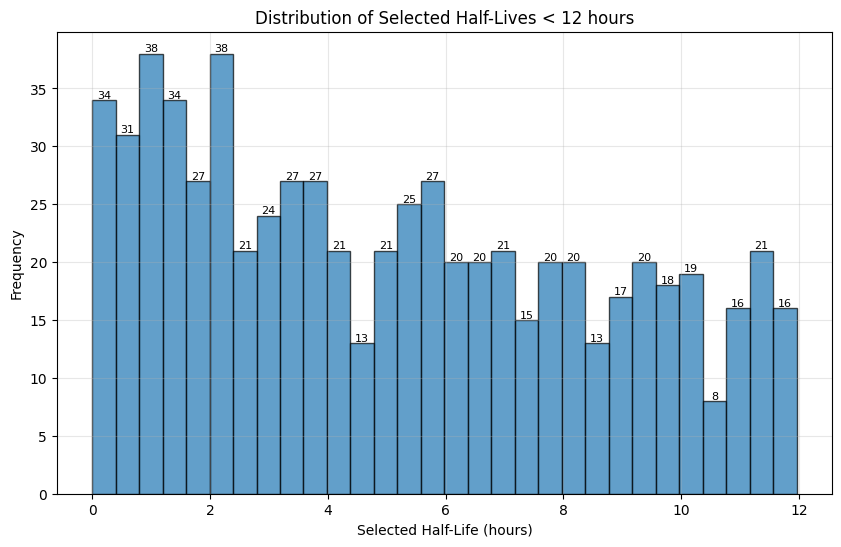

Number of proteins with HL < 12: 672, of 2883 total proteins
Mean: 5.12 hours
Median: 4.82 hours
Min: 0.000000002 hours
Max: 11.96 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [47]:
quick_histogram(data1_capped)

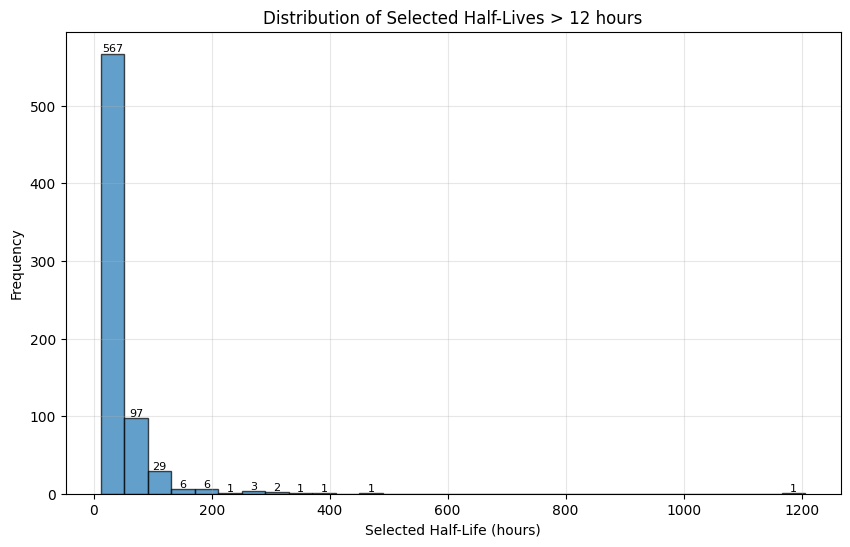

Number of proteins with HL > 12: 715, of 2883 total proteins
Mean: 42.71 hours
Median: 28.63 hours
Min: 12.0021 hours
Max: 1206.56 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [40]:
quick_histogram_over_hours(data1, 12)

In [41]:
# Make a new data frame with the asterisk symbols replaced by the doubling time of the replicate:
data_replaced2 = replace_asterisk_symbols(data)
data_replaced2 = cap_values_at_doubling_time(data_replaced2)
data_replaced2 = recalculate_mean(data_replaced2)
data_replaced2 = calculate_active_half_life(data_replaced2)
data2 = remove_rows_without_half_life(data_replaced2)


# Save data1 to a csv file:
save_to_csv(data2, 'Clim_data2')

data2_capped = cap_half_lives(data2, max_half_life=12)
save_to_csv(data2_capped, 'Clim_data2_capped')

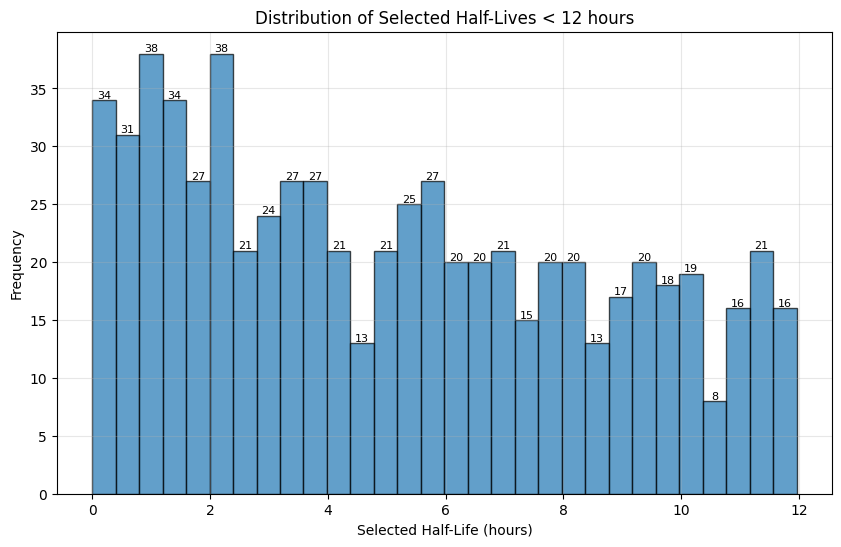

Number of proteins with HL < 12: 672, of 2883 total proteins
Mean: 5.12 hours
Median: 4.82 hours
Min: 0.000000002 hours
Max: 11.96 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [48]:
quick_histogram(data2_capped)

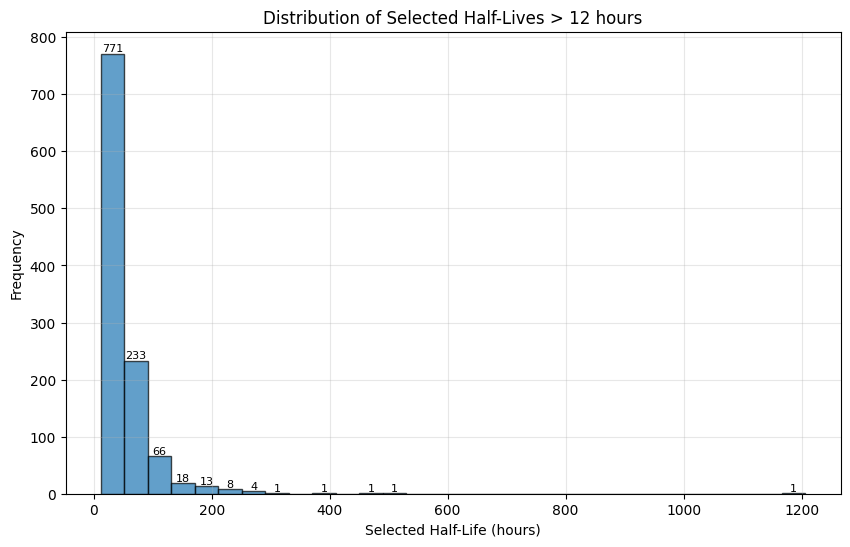

Number of proteins with HL > 12: 1118, of 2883 total proteins
Mean: 49.45 hours
Median: 34.60 hours
Min: 12.0021 hours
Max: 1206.56 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [49]:
quick_histogram_over_hours(data2, 12)

In [60]:
# Make a new data frame with the asterisk symbols are not replaced
data_replaced3 = remove_asterick_symbols(data)
data_replaced3 = recalculate_mean(data_replaced3)
data_replaced3 = calculate_active_half_life(data_replaced3)
data3 = remove_rows_without_half_life(data_replaced3)


# Save data1 to a csv file:
save_to_csv(data3, 'Clim_data3')

data3_capped = cap_half_lives(data3, max_half_life=12)
save_to_csv(data3_capped, 'Clim_data3_capped')

In [77]:
data3

,Protein ID,Gene names,C-lim3_1,C-lim3_2,C-lim3_mean,C-lim6_1,C-lim6_2,C-lim6_mean,C-lim12_1,C-lim12_2,C-lim12_mean,active_HL_3,active_HL_6,active_HL_12,active_HL_mean,active_HL_std,selected_HL
0,sp|A5A614|YCIZ_ECOLI,yciZ,NaN,NaN,NaN,3.932642,3.601144,3.766893,NaN,NaN,NaN,NaN,10.121036,NaN,10.121036,NaN,10.121036
1,sp|O32583|THIS_ECOLI,thiS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.469682,4.469682,NaN,NaN,7.122697,7.122697,NaN,7.122697
2,sp|P00350|6PGD_ECOLI,gnd,3.248315,3.163151,3.205733,5.572427,6.131487,5.851957,10.201045,9.866244,10.033644,12.000000,237.172447,61.231911,103.468119,118.378971,12.000000
3,sp|P00363|FRDA_ECOLI,frdA,2.992966,2.946457,2.969711,6.080384,6.670409,6.375396,13.518765,10.761427,12.140096,294.141533,12.000000,12.000000,106.047178,162.894490,12.000000
4,sp|P00370|DHE4_ECOLI,gdhA,3.076857,2.810401,2.943629,4.462108,4.855534,4.658821,7.653326,6.91881,7.286068,156.656996,20.842054,18.547748,65.348932,79.083423,18.547748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2878,sp|P77162|YKFB_ECOLI,ykfB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.330147,5.330147,NaN,NaN,9.589682,9.589682,NaN,9.589682
2879,sp|Q46892|YGBN_ECOLI,ygbN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.22677,15.226770,NaN,NaN,12.000000,12.000000,NaN,12.000000
2880,sp|Q46943|YQEJ_ECOLI,yqeJ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000,16.000000,NaN,NaN,12.000000,12.000000,NaN,12.000000
2881,sp|Q47274|REQ1_ECOLI,quuD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.733813,8.733813,NaN,NaN,32.088103,32.088103,NaN,32.088103


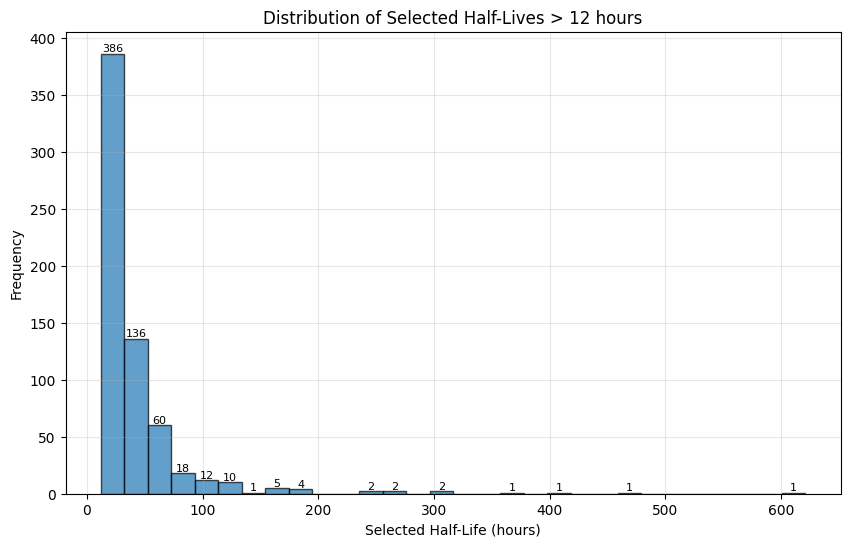

Number of proteins with HL > 12: 642, of 2883 total proteins
Mean: 40.94 hours
Median: 27.25 hours
Min: 12.0021 hours
Max: 621.04 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [61]:
quick_histogram_over_hours(data3, 12)


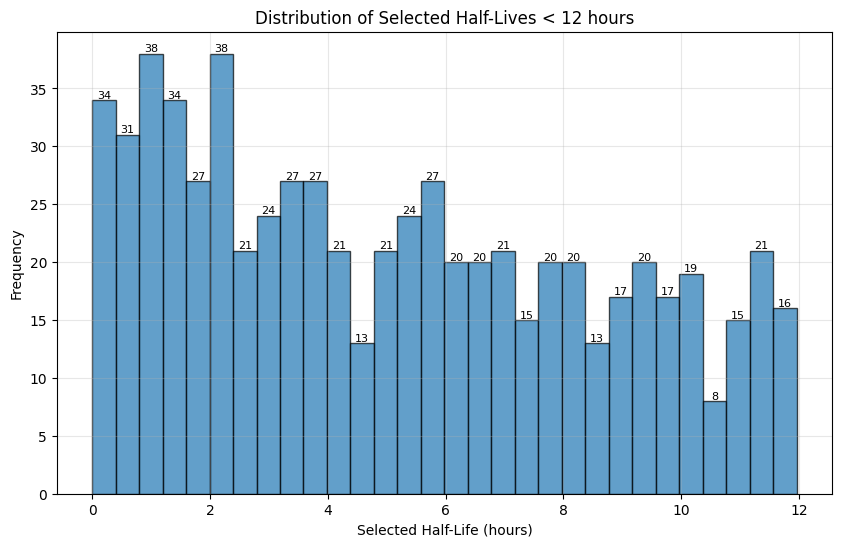

Number of proteins with HL < 12: 669, of 2883 total proteins
Mean: 5.11 hours
Median: 4.72 hours
Min: 0.000000002 hours
Max: 11.96 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [62]:
quick_histogram(data3_capped)

In [63]:
# Make a new data frame with the asterisk symbols replaced by the doubling time of the replicate:
data_filtered1 = replace_asterisk_symbols(data)
data_filtered1 = remove_nan_rows(data_filtered1)
data_filtered1 = recalculate_mean(data_filtered1)
data_filtered1 = calculate_active_half_life(data_filtered1)
data1f = remove_rows_without_half_life(data_filtered1)


# Save data1 to a csv file:
save_to_csv(data1f, 'Clim_data1_filtered')

data1f_capped = cap_half_lives(data1f, max_half_life=12)
save_to_csv(data1f_capped, 'Clim_data1_filtered_and_capped')


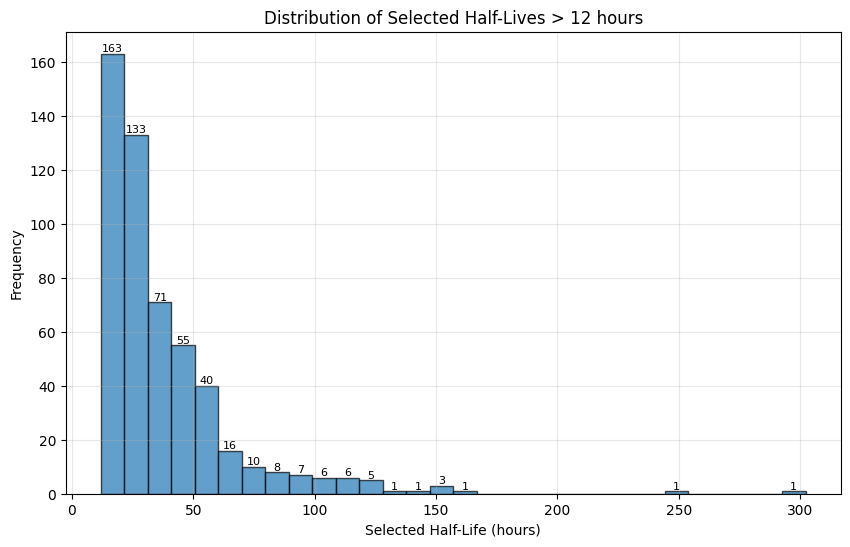

Number of proteins with HL > 12: 528, of 2022 total proteins
Mean: 37.61 hours
Median: 28.00 hours
Min: 12.0021 hours
Max: 302.24 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [64]:
quick_histogram_over_hours(data1f)

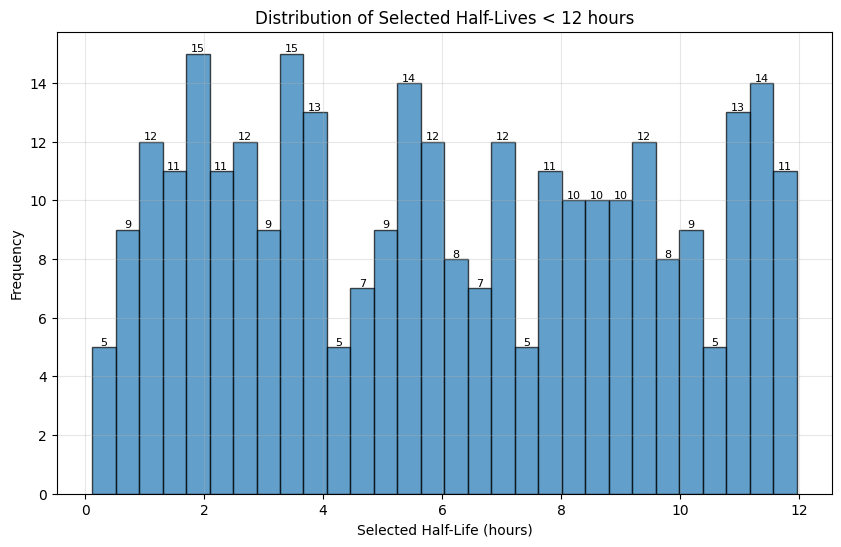

Number of proteins with HL < 12: 304, of 2022 total proteins
Mean: 6.02 hours
Median: 5.77 hours
Min: 0.116915133 hours
Max: 11.96 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [65]:
quick_histogram(data1f_capped)

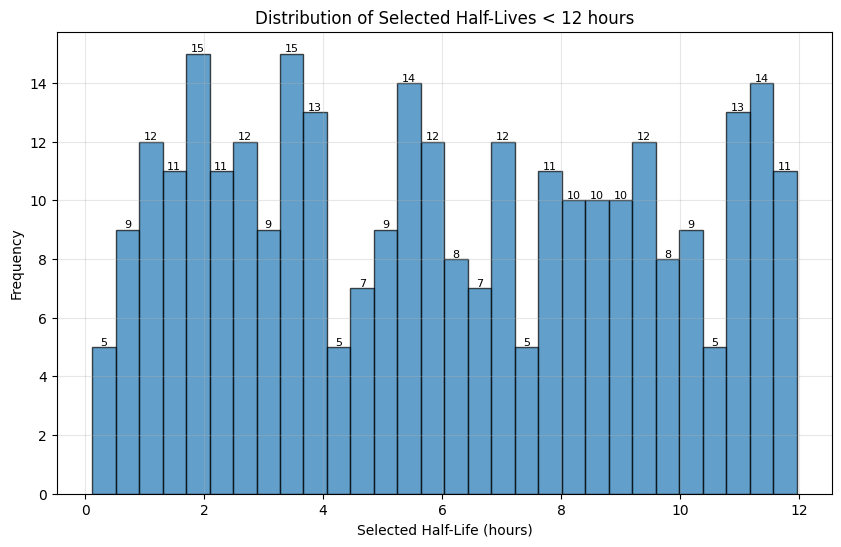

Number of proteins with HL < 12: 304, of 2022 total proteins
Mean: 6.02 hours
Median: 5.77 hours
Min: 0.116915133 hours
Max: 11.96 hours


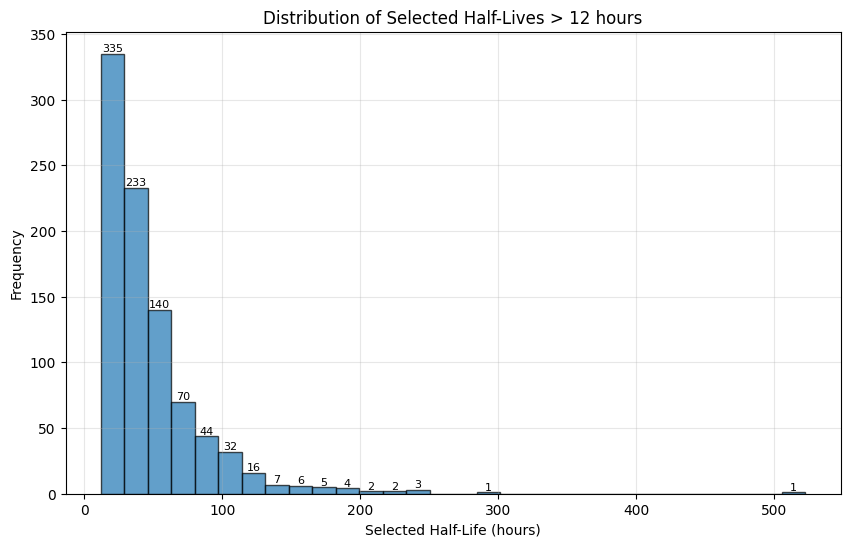

Number of proteins with HL > 12: 901, of 2022 total proteins
Mean: 48.02 hours
Median: 36.71 hours
Min: 12.0021 hours
Max: 522.67 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [69]:

data_filtered2 = remove_nan_rows(data2)

# Save data1 to a csv file:
save_to_csv(data_filtered2, 'Clim_data2_filtered')

data2f_capped = cap_half_lives(data_filtered2, max_half_life=12)
save_to_csv(data2f_capped, 'Clim_data2_filtered_and_capped')

quick_histogram(data2f_capped)
quick_histogram_over_hours(data_filtered2)

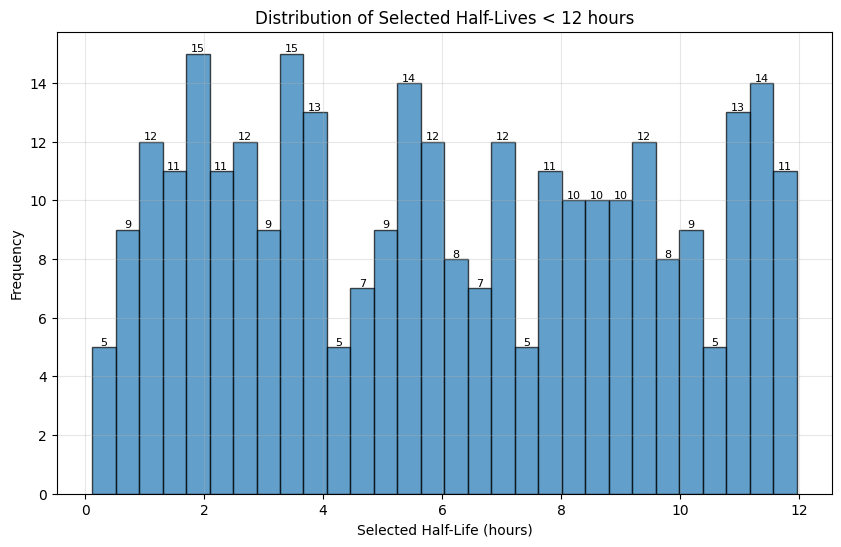

Number of proteins with HL < 12: 304, of 2022 total proteins
Mean: 6.02 hours
Median: 5.77 hours
Min: 0.116915133 hours
Max: 11.96 hours


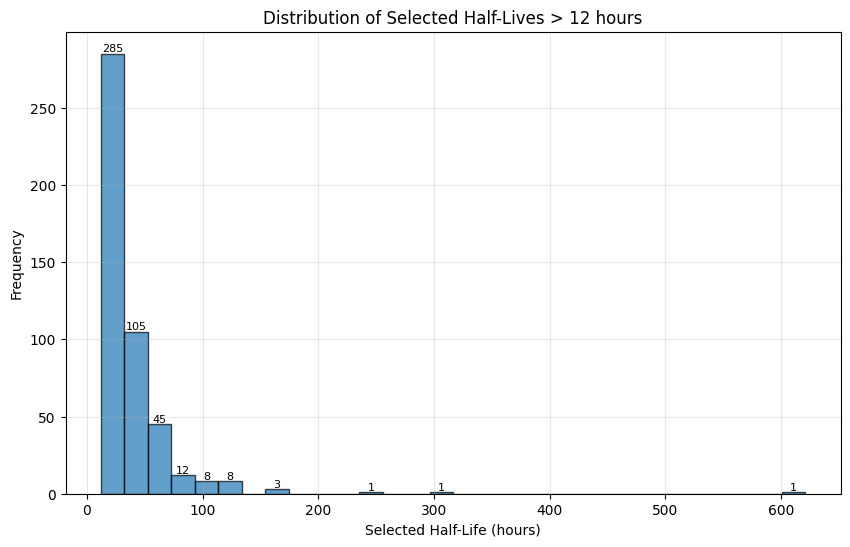

Number of proteins with HL > 12: 469, of 2022 total proteins
Mean: 37.35 hours
Median: 27.22 hours
Min: 12.0021 hours
Max: 621.04 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [70]:
data_filtered3 = remove_nan_rows(data3)

# Save data1 to a csv file:
save_to_csv(data_filtered3, 'Clim_data3_filtered')

data3f_capped = cap_half_lives(data_filtered3, max_half_life=12)
save_to_csv(data3f_capped, 'Clim_data3_filtered_and_capped')

quick_histogram(data3f_capped)
quick_histogram_over_hours(data_filtered3)

In [76]:
# lets save the first few:
save_to_tsv(data1, 'clim1') # just clim!
save_to_tsv(data1_capped, 'clim1a') # clim1 but capped at 12 hours
save_to_tsv(data1f, 'clim1b') # clim1 but filtered to remove nan rows
save_to_tsv(data1f_capped, 'clim1c') # clim1 but filtered to remove nan rows and capped at 12 hours

New HL sort after talk on 3/17


For column C-lim3_mean, doubling time D: 3.0, STD: 0.7103055592122131, max value for half life: 2.289694440787787
For column C-lim6_mean, doubling time D: 6.0, STD: 1.4421482245112607, max value for half life: 4.557851775488739
For column C-lim12_mean, doubling time D: 12.0, STD: 3.279279556526793, max value for half life: 8.720720443473207


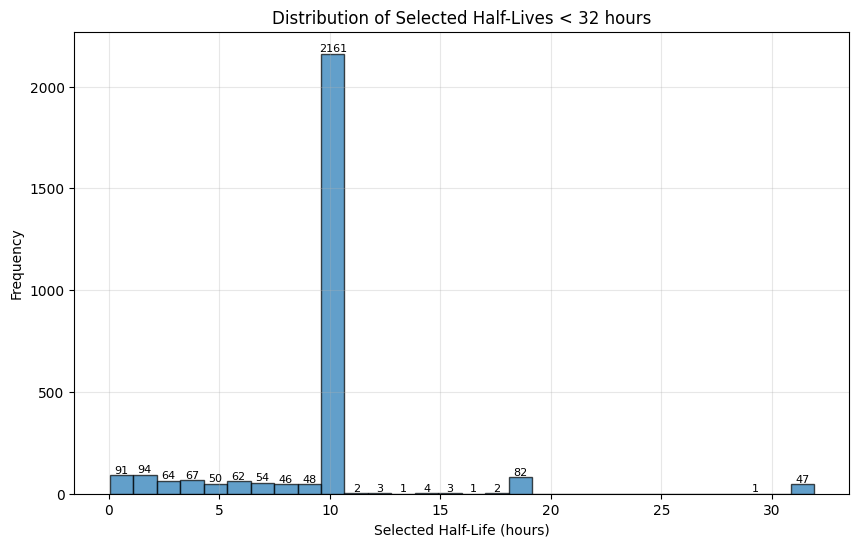

Number of proteins with HL < 32: 2883, of 2883 total proteins
Mean: 9.23 hours
Median: 9.67 hours
Min: 0.033333333 hours
Max: 31.91 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [88]:
# Make a new data frame with the asterisk symbols taken out (dont remove the value though):
data4 = remove_asterick_symbols(data)
data4 = recalculate_mean(data4)
data4 = calculate_active_half_life(data4)
data4 = remove_rows_without_half_life(data4)


# Save data1 to a csv file:
save_to_csv(data4, 'Clim_data4')
save_to_tsv(data4, 'clim4')
quick_histogram(data4, 32)



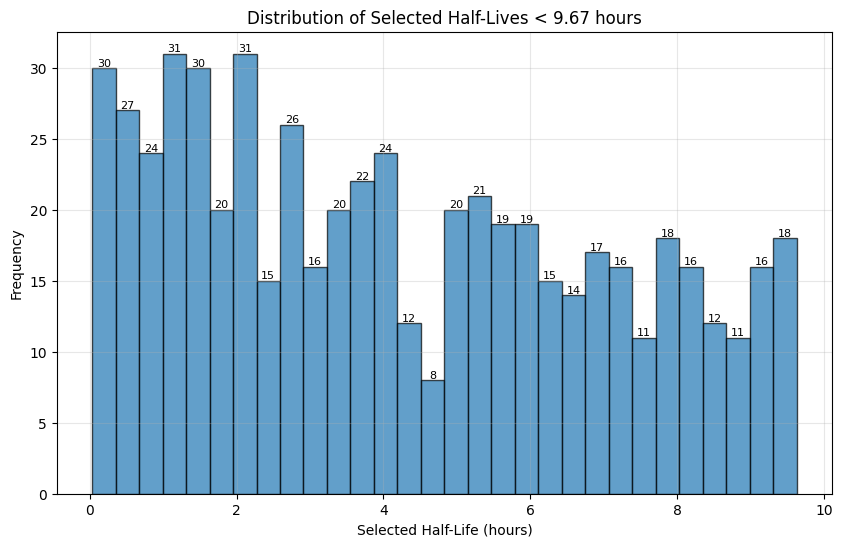

Number of proteins with HL < 9.67: 579, of 2883 total proteins
Mean: 4.21 hours
Median: 3.83 hours
Min: 0.033333333 hours
Max: 9.63 hours


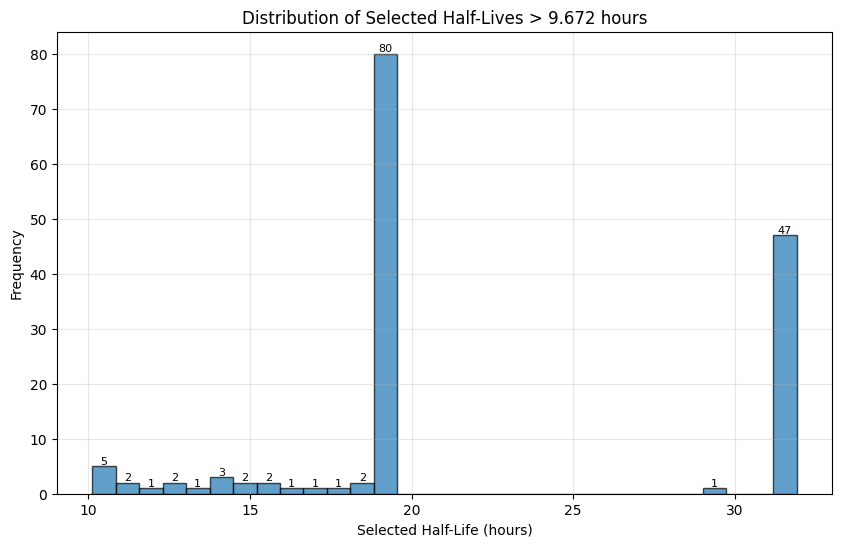

Number of proteins with HL > 9.672: 151, of 2883 total proteins
Mean: 22.27 hours
Median: 18.96 hours
Min: 10.1210 hours
Max: 31.91 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [87]:
quick_histogram(data4, 9.67)
quick_histogram_over_hours(data4, 9.672)

# after talk on 3/24


For column C-lim3_mean, doubling time D: 3.0, STD: 0.7103055592122131, max value for half life: 2.289694440787787
For column C-lim6_mean, doubling time D: 6.0, STD: 1.4421482245112607, max value for half life: 4.557851775488739
For column C-lim12_mean, doubling time D: 12.0, STD: 3.279279556526793, max value for half life: 8.720720443473207


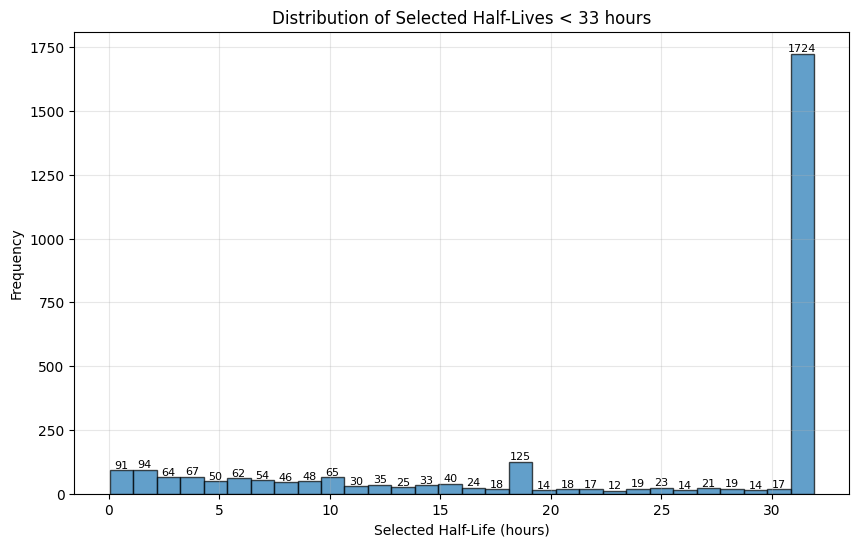

Number of proteins with HL < 33: 2883, of 2883 total proteins
Mean: 23.60 hours
Median: 31.91 hours
Min: 0.033333333 hours
Max: 31.91 hours


<module 'matplotlib.pyplot' from '/Users/miagrahn/.pyenv/versions/wcEcoli3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [12]:
# Make a new data frame with the asterisk symbols taken out (dont remove the value though):
data5 = remove_asterick_symbols(data)
data5 = recalculate_mean(data5)
data5 = calculate_active_half_life_new(data5)
data5 = remove_rows_without_half_life(data5)


# Save data1 to a csv file:
save_to_csv(data5, 'Clim_data5')
save_to_tsv(data5, 'clim')
quick_histogram(data5, 33)

